# Per-Window Cache Baseline Models

In [10]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# crop_embed lives one level up
sys.path.insert(0, str(Path.cwd().parent))

from crop_embed import FixedWindowEmbedder, LinearHead, MLPHead

# CACHE_PATH = Path("/home/andrew.dickson/svar/checkpoints/sativas413_125.ckpt.pt")
CACHE_PATH = Path("/home/andrew.dickson/svar/checkpoints/sativas413_1000.ckpt.pt")
PHENO_PATH = Path("/home/andrew.dickson/rice_data/RiceDiversity_44K_Phenotypes_34traits_PLINK.txt")

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

## 1. Load the per-window cache

`generate_cache.py` writes a torch dict with `cache`, `sample_fp_index`, `metadata`, `unique_fingerprints`, and `sample_ids` at the top level. Top-level keys keep this drop-in compatible with `FixedWindowEmbedder.from_file`, and the extras carry generation provenance.

In [11]:
cache_blob = torch.load(CACHE_PATH, map_location="cpu", weights_only=False)

cache_t          = cache_blob["cache"].float()              # (n_unique_windows, emb_dim)
sample_fp_index  = cache_blob["sample_fp_index"].long()     # (n_samples, n_windows)
# metadata         = cache_blob.get("metadata", {})
cache_samples    = cache_blob.get("sample_ids")             # list[str]

n_samples_cache, n_windows = sample_fp_index.shape
n_unique, emb_dim          = cache_t.shape

print(f"cache           : {tuple(cache_t.shape)}")
print(f"sample_fp_index : {tuple(sample_fp_index.shape)}")
print(f"n_samples={n_samples_cache}  n_windows={n_windows}  n_unique_windows={n_unique}  emb_dim={emb_dim}\n")


cache           : (53005, 768)
sample_fp_index : (383, 20585)
n_samples=383  n_windows=20585  n_unique_windows=53005  emb_dim=768



## 2. Load phenotypes and align to cache samples (NSFTVID)

Same matching scheme as `snp_emb_baseline_models.ipynb`: parse the integer NSFTVID from the suffix of each cache sample ID, keep phenotype rows that overlap, per-trait z-score (NaN-safe).

In [12]:
pheno_raw = pd.read_csv(PHENO_PATH, sep="\t")
pheno_raw["NSFTVID"] = pheno_raw["NSFTVID"].astype(int)
TRAIT_COLS = [c for c in pheno_raw.columns if c not in ("HybID", "NSFTVID")]
print(f"{len(TRAIT_COLS)} trait columns.")

if cache_samples is None:
    raise ValueError("Cache file is missing 'sample_ids' — regenerate with generate_cache.py.")

cache_nsftvid  = [int(s.rsplit("_", 1)[-1]) for s in cache_samples]
cache_id_to_ix = {nid: i for i, nid in enumerate(cache_nsftvid)}

pheno_matched = (
    pheno_raw[pheno_raw["NSFTVID"].isin(cache_id_to_ix)]
    .copy()
    .reset_index(drop=True)
)
print(f"Phenotype rows with matching cache sample: {len(pheno_matched)} / {len(pheno_raw)}")

# Row order = cache index per matched phenotype row.
cache_row_order = np.asarray(
    [cache_id_to_ix[nid] for nid in pheno_matched["NSFTVID"]], dtype=np.int64
)

Y_raw    = pheno_matched[TRAIT_COLS].values.astype(float)   # (n, n_traits)
Y_scaled = np.full_like(Y_raw, np.nan)
for j in range(Y_raw.shape[1]):
    col  = Y_raw[:, j]
    mask = ~np.isnan(col)
    if mask.sum() < 2:
        continue
    mu  = col[mask].mean()
    sd  = col[mask].std(ddof=0)
    Y_scaled[mask, j] = (col[mask] - mu) / (sd if sd > 0 else 1.0)

print(f"Y_scaled shape : {Y_scaled.shape}")

36 trait columns.
Phenotype rows with matching cache sample: 383 / 413
Y_scaled shape : (383, 36)


## 3. Build a sample-level feature matrix (mean-pool over windows)

Sklearn baselines need one vector per sample. `cache_t` holds *unique fingerprint* embeddings and `sample_fp_index` is the sample → fingerprint lookup; materializing the expanded `(n_samples, n_windows, emb_dim)` tensor is too large (≈30 GB for the default rice config).

Instead we chunk over samples — same pattern `LinearHead` uses against `FixedWindowEmbedder` in `demo_train.py` (`embedder(idx).mean(dim=1)`), but precomputed once.

In [19]:
# Mean-pool windows per sample, chunked so we never materialize the full
# (n_samples, n_windows, D) expansion. Same shape `LinearHead` consumes.
BATCH = 8  # samples per chunk; lower if memory-bound (peak ≈ BATCH * n_windows * D * 4 bytes)

fixed_embedder = FixedWindowEmbedder(cache_t, sample_fp_index)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
fixed_embedder.to(device).eval()

sample_vec_t = torch.empty((n_samples_cache, emb_dim), dtype=torch.float32)
with torch.no_grad():
    for i in range(0, n_samples_cache, BATCH):
        j   = min(i + BATCH, n_samples_cache)
        idx = torch.arange(i, j, device=device)
        # fixed_embedder(idx) -> (b, n_windows, D); mean over windows -> (b, D)
        sample_vec_t[i:j] = fixed_embedder(idx).mean(dim=1).cpu()

fixed_embedder.to("cpu")   # release GPU memory; cache_t stays as a CPU buffer
sample_vec = sample_vec_t.numpy()
print(f"sample_vec shape: {sample_vec.shape}")

X_all  = sample_vec[cache_row_order]                  # (n_matched, D), pheno order
X_proc = StandardScaler().fit_transform(X_all)
print(f"X_proc shape: {X_proc.shape}")

# import umap
# reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=5, min_dist=0.3)
# coords  = reducer.fit_transform(X_proc)
# print("UMAP done:", coords.shape)
# fig, ax = plt.subplots(figsize=(8, 6))

# sc = ax.scatter(coords[:, 0], coords[:, 1], s=18, alpha=0.75, linewidths=0)

# ax.set_title("UMAP of sativas413 DNABERT-2 embeddings (413 samples × 768 dims)")
# ax.set_xlabel("UMAP 1")
# ax.set_ylabel("UMAP 2")
# ax.set_aspect("equal", "datalim")

# plt.tight_layout()
# plt.show()

sample_vec shape: (383, 768)
X_proc shape: (383, 768)


## 4. Sklearn baselines (Ridge / KNN / SVR_rbf)

Same CV harness as `snp_emb_baseline_models.ipynb`: 10-fold CV, per-trait Pearson r + R², NaN entries dropped before fitting.

In [20]:
from scipy.stats import pearsonr
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score

EVAL_TRAITS = [
    "Alkali spreading value",
    "Amylose content",
    "Panicle number per plant",
    "Protein content",
    "Seed length",
    "Seed number per panicle",
]

MODELS = [
    ("Ridge",   Ridge(alpha=4.0)),
    ("KNN",     KNeighborsRegressor(n_neighbors=5)),
    ("SVR_rbf", SVR(kernel="rbf")),
]

def cv_eval(X_feat, y, models, n_splits=10, random_state=SEED):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    out = {name: {"pearson_r": [], "r2": []} for name, _ in models}
    for tr, te in kf.split(X_feat):
        for name, model in models:
            model.fit(X_feat[tr], y[tr])
            y_pred = model.predict(X_feat[te])
            r, _   = pearsonr(y[te], y_pred)
            out[name]["pearson_r"].append(r)
            out[name]["r2"].append(r2_score(y[te], y_pred))
    return {
        name: {
            "pearson_r":     float(np.mean(v["pearson_r"])),
            "pearson_r_std": float(np.std(v["pearson_r"])),
            "r2":            float(np.mean(v["r2"])),
            "r2_std":        float(np.std(v["r2"])),
        }
        for name, v in out.items()
    }

rows = []
for trait in EVAL_TRAITS:
    j     = TRAIT_COLS.index(trait)
    y_t   = Y_scaled[:, j]
    mask  = ~np.isnan(y_t)
    if mask.sum() < 30:
        print(f"Skipping {trait!r} — only {mask.sum()} non-NaN")
        continue
    res = cv_eval(X_proc[mask], y_t[mask], MODELS)
    for name, m in res.items():
        rows.append({
            "Trait":          trait,
            "Model":          name,
            "Pearson r":      round(m["pearson_r"],     4),
            "R\u00b2":         round(m["r2"],            4),
            "R\u00b2 std":     round(m["r2_std"],        4),
            "Pearson r std":  round(m["pearson_r_std"], 4),
            "n_samples":      int(mask.sum()),
        })

baseline_df = (
    pd.DataFrame(rows)
    .sort_values(["Trait", "Pearson r"], ascending=[True, False])
    .reset_index(drop=True)
)
baseline_df

,Trait,Model,Pearson r,R²,R² std,Pearson r std,n_samples
0,Alkali spreading value,SVR_rbf,0.5815,0.3095,0.1089,0.1130,374
1,Alkali spreading value,KNN,0.4734,0.1960,0.1187,0.1070,374
2,Alkali spreading value,Ridge,0.2884,-0.8380,0.6245,0.1756,374
3,Amylose content,SVR_rbf,0.7501,0.5468,0.1737,0.1118,372
4,Amylose content,KNN,0.7274,0.5050,0.0831,0.0609,372
5,Amylose content,Ridge,0.5533,-0.3169,0.5994,0.1217,372
6,Panicle number per plant,SVR_rbf,0.8103,0.6466,0.0674,0.0416,345
7,Panicle number per plant,KNN,0.7603,0.5607,0.0982,0.0591,345
8,Panicle number per plant,Ridge,0.5685,-0.0883,0.3092,0.1109,345
9,Protein content,SVR_rbf,0.4082,0.1405,0.1230,0.1544,364


In [63]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_proc, Y_scaled, test_size=0.3, random_state=42)
import numpy as np
import matplotlib.pyplot as plt

def masked_mse(pred, target):
    m = ~torch.isnan(target)
    diff = (pred - torch.nan_to_num(target)) * m     # finite everywhere; 0 at masked entries
    return (diff ** 2).sum(dim=0) / m.sum(dim=0).clamp(min=1)


EPOCHS = 15

def run_epoch(loader, train_mode):
    head.train(train_mode)
    sse = torch.zeros(n_traits, device=device)
    cnt = torch.zeros(n_traits, device=device)
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        pred = head(xb)
        if train_mode:
            optim.zero_grad()
            masked_mse(pred, yb).mean().backward()
            optim.step()
        with torch.no_grad():
            m = ~torch.isnan(yb)
            sse += torch.where(m, (pred - yb) ** 2, 0.0).sum(dim=0)
            cnt += m.sum(dim=0)
    return (sse / cnt).cpu().numpy()          # per-trait MSE, shape (n_traits,)

HEAD_KIND   = "linear"      # "linear" or "mlp"
HIDDEN_DIM  = 3000
MLP_DROPOUT = 0.6
STEPS       = 1000
LR          = 1e-3
WD          = 1e-4
BATCH       = 32
LOG_EVERY   = 10

n_traits = y_train.shape[1]
if HEAD_KIND == "linear":
    head = LinearHead(emb_dim=emb_dim, n_traits=n_traits)
else:
    head = MLPHead(emb_dim=emb_dim, n_traits=n_traits,
                   hidden_dim=HIDDEN_DIM, dropout=MLP_DROPOUT)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
head.to(device).train()
optim = torch.optim.Adam(head.parameters(), lr=LR, weight_decay=WD)
torch.manual_seed(SEED)

from torch.utils.data import TensorDataset, DataLoader

X_train_t = torch.as_tensor(X_train, dtype=torch.float32)[:, None, :]
y_train_t = torch.as_tensor(y_train, dtype=torch.float32)
X_test_t  = torch.as_tensor(X_test,  dtype=torch.float32)[:, None, :]
y_test_t  = torch.as_tensor(y_test,  dtype=torch.float32)

train_ds = TensorDataset(X_train_t, y_train_t)
test_ds  = TensorDataset(X_test_t,  y_test_t)

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False)


In [64]:
train_hist, val_hist = [], []
for epoch in range(EPOCHS):
    tr = run_epoch(train_loader, train_mode=True)
    with torch.no_grad():
        va = run_epoch(test_loader, train_mode=False)
    train_hist.append(tr)
    val_hist.append(va)
    print(f"epoch {epoch:3d} | train {tr.mean():.4f} | val {va.mean():.4f}")

train_hist = np.array(train_hist)             # (EPOCHS, n_traits)
val_hist   = np.array(val_hist)

epoch   0 | train 1.0379 | val 0.9002
epoch   1 | train 0.7472 | val 0.8482
epoch   2 | train 0.6177 | val 0.8002
epoch   3 | train 0.5415 | val 0.7959
epoch   4 | train 0.4929 | val 0.7721
epoch   5 | train 0.4535 | val 0.7767
epoch   6 | train 0.4216 | val 0.7770
epoch   7 | train 0.3915 | val 0.7775
epoch   8 | train 0.3675 | val 0.7662
epoch   9 | train 0.3465 | val 0.7661
epoch  10 | train 0.3297 | val 0.7696
epoch  11 | train 0.3122 | val 0.7696
epoch  12 | train 0.2999 | val 0.7737
epoch  13 | train 0.2882 | val 0.7720
epoch  14 | train 0.2753 | val 0.7807


In [65]:
import numpy as np

head.eval()
preds, targs = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        preds.append(head(xb.to(device)).cpu())
        targs.append(yb)
preds = torch.cat(preds).numpy()
targs = torch.cat(targs).numpy()

pcc = np.full(n_traits, np.nan)
for j in range(n_traits):
    m = ~np.isnan(targs[:, j])
    p, t = preds[m, j], targs[m, j]
    if m.sum() > 1 and p.std() > 0 and t.std() > 0:
        pcc[j] = np.corrcoef(p, t)[0, 1]
    print(f"trait {j:2d} | n {m.sum():5d} | PCC {pcc[j]:.4f}")

print(f"\nmean PCC: {np.nanmean(pcc):.4f}")


trait  0 | n   103 | PCC 0.5794
trait  1 | n    86 | PCC 0.3574
trait  2 | n   103 | PCC 0.3446
trait  3 | n    98 | PCC 0.2277
trait  4 | n    86 | PCC 0.3462
trait  5 | n   107 | PCC 0.5264
trait  6 | n    83 | PCC 0.5192
trait  7 | n   105 | PCC 0.4203
trait  8 | n   105 | PCC 0.6876
trait  9 | n   101 | PCC 0.1071
trait 10 | n   104 | PCC 0.7518
trait 11 | n   106 | PCC 0.6182
trait 12 | n   104 | PCC 0.5581
trait 13 | n   104 | PCC 0.5204
trait 14 | n   105 | PCC 0.4576
trait 15 | n   105 | PCC 0.5497
trait 16 | n   105 | PCC 0.2704
trait 17 | n   106 | PCC 0.6150
trait 18 | n   106 | PCC 0.7525
trait 19 | n   106 | PCC 0.7440
trait 20 | n   106 | PCC 0.5971
trait 21 | n   106 | PCC 0.6761
trait 22 | n   106 | PCC 0.7357
trait 23 | n   106 | PCC 0.6887
trait 24 | n   106 | PCC 0.7149
trait 25 | n   106 | PCC 0.7095
trait 26 | n   106 | PCC 0.7316
trait 27 | n   106 | PCC 0.2613
trait 28 | n   106 | PCC 0.4473
trait 29 | n   100 | PCC 0.4696
trait 30 | n   110 | PCC 0.6190
trait 31

In [46]:
train_loss_l[0]

array(1.0877475, dtype=float32)

In [32]:
import numpy as np
from sklearn.base import clone
from sklearn.neural_network import MLPRegressor

y_train_arr = np.asarray(y_train, dtype=np.float64)
y_test_arr  = np.asarray(y_test,  dtype=np.float64)
X_train_arr = np.asarray(X_train, dtype=np.float64)
X_test_arr  = np.asarray(X_test,  dtype=np.float64)

base = MLPRegressor(
    hidden_layer_sizes=(128, 128, 128,),
    activation="relu",
    solver="adam",
    alpha=1e-2,
    batch_size=32,
    learning_rate_init=1e-3,
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=SEED,
)

n_traits = y_train_arr.shape[1]
models = []
preds_test = np.full_like(y_test_arr, np.nan)

for j in range(n_traits):
    tr_mask = ~np.isnan(y_train_arr[:, j])
    model = clone(base)
    model.fit(X_train_arr[tr_mask], y_train_arr[tr_mask, j])
    models.append(model)
    preds_test[:, j] = model.predict(X_test_arr)

    te_mask = ~np.isnan(y_test_arr[:, j])
    mse_j = np.mean((preds_test[te_mask, j] - y_test_arr[te_mask, j]) ** 2)
    print(f"trait {j:2d} | n_train {tr_mask.sum():5d} | test MSE {mse_j:.4f}")

overall_mask = ~np.isnan(y_test_arr)
overall_mse = np.mean((preds_test[overall_mask] - y_test_arr[overall_mask]) ** 2)
print(f"\noverall masked test MSE: {overall_mse:.4f}")


trait  0 | n_train   244 | test MSE 0.6307
trait  1 | n_train   198 | test MSE 1.4963
trait  2 | n_train   231 | test MSE 0.7951
trait  3 | n_train   227 | test MSE 1.2059
trait  4 | n_train   197 | test MSE 1.2353
trait  5 | n_train   249 | test MSE 0.5669
trait  6 | n_train   182 | test MSE 0.8146
trait  7 | n_train   245 | test MSE 0.8617
trait  8 | n_train   245 | test MSE 0.6110
trait  9 | n_train   241 | test MSE 1.1254
trait 10 | n_train   241 | test MSE 0.4719
trait 11 | n_train   249 | test MSE 0.4722
trait 12 | n_train   244 | test MSE 0.8031
trait 13 | n_train   244 | test MSE 0.8106
trait 14 | n_train   244 | test MSE 0.8143
trait 15 | n_train   245 | test MSE 0.8062
trait 16 | n_train   244 | test MSE 1.1041
trait 17 | n_train   244 | test MSE 0.5507
trait 18 | n_train   244 | test MSE 0.6133
trait 19 | n_train   244 | test MSE 0.6609
trait 20 | n_train   244 | test MSE 0.6805
trait 21 | n_train   244 | test MSE 0.5223
trait 22 | n_train   244 | test MSE 0.6148
trait 23 | 

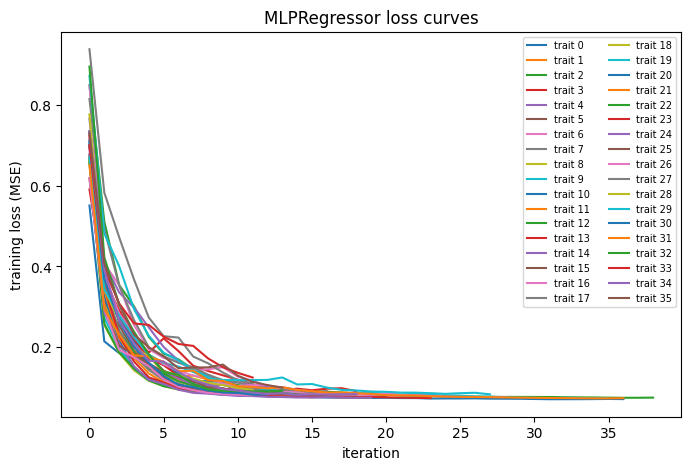

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
for j, model in enumerate(models):
    plt.plot(model.loss_curve_, label=f"trait {j}")
plt.xlabel("iteration")
plt.ylabel("training loss (MSE)")
plt.title("MLPRegressor loss curves")
plt.legend(fontsize=7, ncol=2)
plt.show()


## 5. Minimal inline training loop on per-window embeddings

Instead of calling `crop_embed.train()`, the cell below is an explicit ~20-line loop: random mini-batch of sample indices → `FixedWindowEmbedder.forward` → head → masked MSE → Adam step. Same masked-MSE objective, but everything is in plain view so it's easy to swap in early stopping, per-trait training, a different optimizer, or input scaling.

We rebuild a `FixedWindowEmbedder` from the loaded buffers (no VCF/FASTA needed — the cache is self-contained) and reuse the train/test split from above.

In [95]:
# Targets aligned to cache.sample row order (NaN for samples without phenotype).
Y_aligned = np.full((n_samples_cache, len(TRAIT_COLS)), np.nan, dtype=np.float64)
Y_aligned[cache_row_order] = Y_scaled
Y_tensor  = torch.tensor(Y_aligned, dtype=torch.float32)

# Train/test split over samples that *have* phenotype data.
has_pheno = np.where(~np.isnan(Y_aligned).all(axis=1))[0]
rng       = np.random.default_rng(SEED)
perm      = rng.permutation(has_pheno)
n_test    = round(len(perm) * 0.30)
test_ix   = torch.tensor(perm[:n_test],  dtype=torch.long)
train_ix  = torch.tensor(perm[n_test:],  dtype=torch.long)
print(f"train/test: {len(train_ix)} / {len(test_ix)}  (of {len(has_pheno)} phenotyped samples)")

fixed = FixedWindowEmbedder(cache_t, sample_fp_index)

HEAD_KIND   = "mlp"      # "linear" or "mlp"
HIDDEN_DIM  = emb_dim
MLP_DROPOUT = 0.1
STEPS       = 1000
LR          = 1e-5
WD          = 1e-4
BATCH       = 32
LOG_EVERY   = 10

n_traits = Y_tensor.shape[1]
if HEAD_KIND == "linear":
    head = LinearHead(emb_dim=emb_dim, n_traits=n_traits)
else:
    head = MLPHead(emb_dim=emb_dim, n_traits=n_traits,
                   hidden_dim=HIDDEN_DIM, dropout=MLP_DROPOUT)

train/test: 268 / 115  (of 383 phenotyped samples)


In [100]:
X_train_tensor = X_proc[train_ix, :]
X_test_tensor = X_proc[test_ix, :]
Y_train_tensor = Y_tensor[train_ix, :]
Y_test_tensor = Y_tensor[test_ix, :]

In [ ]:
# ── Minimal training loop ─────────────────────────────────────────────────
# Random mini-batches of sample indices → fixed(sel) gives (B, n_windows, D),
# head pools+predicts → masked MSE over non-NaN targets, Adam step.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
head.to(device).train()
fixed.to(device).eval()           # no trainable params; .to() moves the cache buffer
Y_dev       = Y_tensor.to(device)
train_idx_d = train_ix.to(device)
test_idx_d  = test_ix.to(device)


log_data = []

def masked_mse(pred, target):
    m = ~torch.isnan(target)
    return ((pred[m] - target[m]) ** 2).mean() if m.any() else pred.sum() * 0.0

for step in range(1, STEPS + 1):
    sel  = train_idx_d[torch.randint(0, len(train_idx_d), (BATCH,), device=device)]
    loss = masked_mse(head(fixed(sel)), Y_dev[sel])
    log_data.append(loss.item())
    optim.zero_grad()
    loss.backward()
    optim.step()
    if step % LOG_EVERY == 0 or step == STEPS:
        head.eval()
        with torch.no_grad():
            val_loss = masked_mse(head(fixed(test_idx_d)), Y_dev[test_idx_d]).item()
        head.train()
        print(f"step {step:4d}  train_loss={loss.item():.4f}  val_loss={val_loss:.4f}")

step   10  train_loss=0.9579  val_loss=1.0494
step   20  train_loss=1.1136  val_loss=1.0497
step   30  train_loss=1.0354  val_loss=1.0502
step   40  train_loss=1.0806  val_loss=1.0505
step   50  train_loss=0.8873  val_loss=1.0507
step   60  train_loss=1.1782  val_loss=1.0509
step   70  train_loss=1.0485  val_loss=1.0510
step   80  train_loss=0.8462  val_loss=1.0514
step   90  train_loss=1.1918  val_loss=1.0517
step  100  train_loss=0.9215  val_loss=1.0523
step  110  train_loss=0.9945  val_loss=1.0527
step  120  train_loss=0.9504  val_loss=1.0531
step  130  train_loss=0.9128  val_loss=1.0534
step  140  train_loss=1.1065  val_loss=1.0537
step  150  train_loss=1.0228  val_loss=1.0540
step  160  train_loss=0.8165  val_loss=1.0542
step  170  train_loss=0.9215  val_loss=1.0545
step  180  train_loss=0.9325  val_loss=1.0548
step  190  train_loss=0.9890  val_loss=1.0551
step  200  train_loss=0.9978  val_loss=1.0552
step  210  train_loss=0.9531  val_loss=1.0552
step  220  train_loss=1.0422  val_

In [ ]:
mlp = MLPRegressor(
        hidden_layer_sizes=(emb_dim, emb_dim, emb_dim, 128, 128),  # 768, same as PyTorch MLPHead
        activation="relu",
        solver="adam",
        alpha=1e-2,
        batch_size=32,
        learning_rate_init=1e-3,
        max_iter=500,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=SEED, verbose=True,
    )
mlp.fit(X_train_tensor, Y_train_tensor[:, 0])

ValueError: Input y contains NaN.

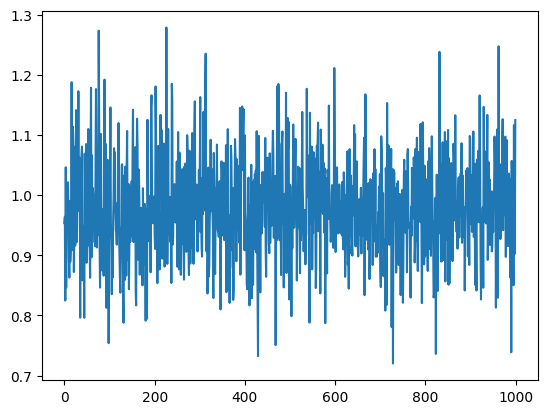

In [97]:
plt.plot(log_data)
plt.show()

In [79]:
train_dataset[0][1].shape

torch.Size([36])

### Per-trait Pearson r on the held-out test split

Compares directly to the baseline table above — same test samples, same trait z-scoring, just a per-window-aware head instead of a sklearn model on the mean-pooled vector.

In [63]:
device = next(head.parameters()).device
head.eval()
fixed.to(device).eval()

with torch.no_grad():
    test_pred = head(fixed(test_ix.to(device))).cpu().numpy()
test_targ = Y_tensor[test_ix].numpy()

head_rows = []
for j, trait in enumerate(TRAIT_COLS):
    mask = ~np.isnan(test_targ[:, j])
    if mask.sum() < 5:
        continue
    r, _ = pearsonr(test_targ[mask, j], test_pred[mask, j])
    head_rows.append({
        "Trait":     trait,
        "Model":     f"{HEAD_KIND}_head",
        "Pearson r": round(float(r), 4),
        "R\u00b2":    round(float(r2_score(test_targ[mask, j], test_pred[mask, j])), 4),
        "n_test":    int(mask.sum()),
    })

head_df = (
    pd.DataFrame(head_rows)
    .set_index("Trait")
    .loc[[t for t in EVAL_TRAITS if t in {r["Trait"] for r in head_rows}] +
         [t for t in TRAIT_COLS if t not in EVAL_TRAITS and t in {r["Trait"] for r in head_rows}]]
    .reset_index()
)
head_df.head(20)

IndexError: index 1 is out of bounds for axis 1 with size 1

In [ ]:
# Side-by-side comparison: best sklearn baseline vs head model, for EVAL_TRAITS.
best_baseline = (
    baseline_df.loc[baseline_df.groupby("Trait")["Pearson r"].idxmax()]
    [["Trait", "Model", "Pearson r"]]
    .rename(columns={"Model": "Best baseline", "Pearson r": "Baseline r"})
)
head_part = head_df[head_df["Trait"].isin(EVAL_TRAITS)][["Trait", "Pearson r"]].rename(
    columns={"Pearson r": f"{HEAD_KIND}_head r"}
)
comparison = best_baseline.merge(head_part, on="Trait", how="outer").sort_values("Trait")
comparison

## 6. Sanity check — same MLP architecture via sklearn

If the PyTorch `MLPHead` underperforms SVR_rbf because of *training* (multitask MSE, single 30% split, batch SGD on a ~270-sample fold), then a per-trait sklearn `MLPRegressor` with the same hidden width should slot into the 10-fold CV harness and either:

* roughly match SVR_rbf — meaning the PyTorch head's gap is training/evaluation asymmetry, not architecture; or
* still lose to SVR_rbf by a similar margin — meaning the RBF kernel's inductive bias is genuinely better-suited to this signal than any MLP at this sample size.

Same `cv_eval` (10-fold, per-trait, NaN-masked) as section 4 — just an extra model in the list.

In [65]:
EVAL_TRAITS

['Alkali spreading value',
 'Amylose content',
 'Panicle number per plant',
 'Protein content',
 'Seed length',
 'Seed number per panicle']

In [69]:
from sklearn.neural_network import MLPRegressor

# Mirror the PyTorch MLPHead architecture + optimizer where possible:
#   nn.Linear(emb_dim, hidden_dim) -> activation -> Dropout -> nn.Linear(hidden_dim, n_traits)
#   Adam, lr=1e-3, weight_decay=1e-2 (alpha is sklearn's L2 coefficient)
# sklearn has no GELU; ReLU is the closest swap and irrelevant at this width.
MLP_MODELS = [
    ("SVR_rbf",  SVR(kernel="rbf")),  # incumbent reference
    ("MLP_wide", MLPRegressor(
        hidden_layer_sizes=(emb_dim, emb_dim, emb_dim, 128, 128),  # 768, same as PyTorch MLPHead
        activation="relu",
        solver="adam",
        alpha=1e-2,
        batch_size=32,
        learning_rate_init=1e-3,
        max_iter=500,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=SEED,
    )),
    ("MLP_narrow", MLPRegressor(
        hidden_layer_sizes=(128, 128, 128,),
        activation="relu",
        solver="adam",
        alpha=1e-2,
        batch_size=32,
        learning_rate_init=1e-3,
        max_iter=500,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=SEED,
    )),
]

mlp_rows = []
test_traits = ['Panicle number per plant']
for trait in test_traits:
    j    = TRAIT_COLS.index(trait)
    y_t  = Y_scaled[:, j]
    mask = ~np.isnan(y_t)
    if mask.sum() < 30:
        continue
    res = cv_eval(X_proc[mask], y_t[mask], MLP_MODELS)
    for name, m in res.items():
        mlp_rows.append({
            "Trait":          trait,
            "Model":          name,
            "Pearson r":      round(m["pearson_r"],     4),
            "R\u00b2":         round(m["r2"],            4),
            "Pearson r std":  round(m["pearson_r_std"], 4),
            "n_samples":      int(mask.sum()),
        })

mlp_df = (
    pd.DataFrame(mlp_rows)
    .pivot(index="Trait", columns="Model", values="Pearson r")
    .loc[test_traits]
    [["SVR_rbf", "MLP_wide", "MLP_narrow"]]
)
mlp_df

Model,SVR_rbf,MLP_wide,MLP_narrow
Trait,,,
Panicle number per plant,0.8103,0.7922,0.772
